In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm import tqdm
import pickle
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.optimize import minimize_scalar
import ot
import os

In [90]:
import mpmath as mp
mp.mp.dps = 50

In [3]:
def probit_moment(k, N, r):        # r = 1 or 2
    beta_norm = mp.beta(k, N+1-k)
    SQRT2   = mp.sqrt(2)
    SQRT2PI = mp.sqrt(2*mp.pi)
    
    # Standard–normal PDF   φ(z)  = (2π)^{-½} · e^{ -z² / 2 }
    phi  = lambda z: mp.e**(-z*z/2) / SQRT2PI
    
    # Standard–normal CDF   Φ(z)  = ½ · [ 1 + erf( z / √2 ) ]
    Phi  = lambda z: 0.5 * (1 + mp.erf(z / SQRT2))
    # phi   = norm.pdf
    # Phi   = norm.cdf
    integrand = lambda z: (z**r *
                           Phi(z)**(k-1) *
                           (1-Phi(z))**(N-k) *
                           phi(z))
    return float(mp.quad(integrand, [-mp.inf, mp.inf]) / beta_norm)

def cN_gaussian(N, m1s=None):
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return np.mean(m1s**2)

def expected_wasserstein_loss_gaussian(mu1, sigma1, mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return (mu1 - mu2)**2 + sigma1**2 + sigma2**2 - 2*cN_gaussian(N, m1s=m1s)*sigma1*sigma2

def true_wass_loss_gaussian(mu1, sigma1, mu2, sigma2):
    return (mu1 - mu2)**2 + (sigma1 - sigma2)**2

def analytic_sol_gaussian(mu1, sigma1, N, m1s = None):
    # argmin of E_{\mu,\nu}[W(\hat{\mu}_N, \hat{\nu}_N)]
    return mu1, sigma1 * cN_gaussian(N, m1s=m1s)

def cN_exponential(N):
    k   = np.arange(1.0, N + 1.0)
    return float(0.5*np.mean([(mp.digamma(N+1-k[i]) - mp.digamma(N+1))**2 for i in range(N)]))

def b1s_exponential(N):
    return np.array([float(mp.digamma(N+1) - mp.digamma(N-i)) for i in range(N)]) / np.sqrt(2)

def d_infty_exp():
    # Standard normal quantile function (inverse CDF)
    phi_inv = lambda u: mp.sqrt(2) * mp.erfinv(2*u - 1)
    
    # Integrand
    f = lambda u: phi_inv(u) * mp.log(1 - u)
    
    # Perform the integration
    return float(-(1/mp.sqrt(2)) * mp.quad(f, [0, 1]))

def expected_wasserstein_loss_exponential(a1, a2, N, cN = None):
    th1 = np.sqrt(2)/a1
    th2 = np.sqrt(2)/a2
    if cN is None:
        cN = cN_exponential(N)
    return th1**2 + th2**2 - 2*cN*th1*th2

def analytic_sol_exponential(a1, N, cN = None):
    th1 = np.sqrt(2)/a1
    if cN is None:
        cN = cN_exponential(N)
    th_hat = cN*th1
    return np.sqrt(2)/th_hat

def true_wass_loss_exponential(a1, a2):
    return 2*(1/a1 - 1/a2)**2

def true_wass_loss_exponential_gaussian(mu, sigma, theta, d_infty):
    return mu**2 + sigma**2 - 2*theta*mu/np.sqrt(2) + theta**2 - 2*theta*sigma*d_infty

def analytic_sol_exponential_gaussian(theta, d_infty):
    return theta / np.sqrt(2), d_infty * theta

def expected_W_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    return -2.0 * theta * sigma2 * np.mean(m1s_exp*m1s) - 2*mu2*theta/np.sqrt(2) + mu2**2 + sigma2**2 + theta**2

def expected_W_exponential_gaussian_grad(theta, mu2, sigma2, N, m1s_exp=None, m1s=None):
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    grad0 = 2*mu2 - 2*theta/np.sqrt(2)
    grad1 = 2*sigma2 - np.mean(2.0 * m1s_exp*m1s)*theta
    return np.array([grad0, grad1])

def analytic_sol_expected_W_exponential_gaussian(theta, N, m1s_exp=None, m1s=None, alpha = 0):
    # argmin_\nu of E[W(\hat{\mu}_N, \nu)]
    if m1s_exp is None:
        m1s_exp = b1s_exponential(N)
    if m1s is None:
        m1s = np.array([probit_moment(k+1, N, 1) for k in range(N)])
    sigma_hat = np.mean(m1s_exp*m1s)*theta / (1 - 2*alpha * (1-np.mean(m1s**2)))
    return theta/np.sqrt(2), max(sigma_hat, 0)

In [142]:
def expected_wasserstein_loss_gaussian_self_grad(mu2, sigma2, N, m1s=None):
    k   = np.arange(1.0, N + 1.0)
    if m1s is None:
        m1s = np.array([probit_moment(k[i], N, 1) for i in range(N)])
    return np.array([0, 4*(1-cN_gaussian(N, m1s=m1s))*sigma2])

In [92]:
def load_results_misspecified(reg, N_set_merge = [2, 5, 10, 20, 50, 100]):
    filename1 = f'./entreg_results/results_full_eps{reg}_N10_100_misspec.pickle'
    # load from pickle file
    if os.path.exists(filename1):
        with open(filename1, "rb") as f:
            results1 = pickle.load(f)
    
    filename2 = f'./entreg_results/results_full_eps{reg}_N20_N50_misspec.pickle'
    # load from pickle file
    if os.path.exists(filename2):
        with open(filename2, "rb") as f:
            results2 = pickle.load(f)
    
    filename3 = f'./entreg_results/results_full_eps{reg}_N2_N5_misspec.pickle'
    # load from pickle file
    if os.path.exists(filename3):
        with open(filename3, "rb") as f:
            results3 = pickle.load(f)
    
    results_merge = dict()
    
    N_set1 = [10, 100]
    N_set2 = [20, 50]
    N_set3 = [2, 5]
    
    for key in results1.keys():
        # print(key)
        if key == "t_per":
            continue
        shape = results1[key].shape
        new_shape = (len(N_set_merge), shape[1], shape[2])
        results_merge[key] = np.empty(new_shape, dtype=np.float64)
        for i, N in enumerate(N_set1):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results1[key][i]
        for i, N in enumerate(N_set2):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results2[key][i]
        for i, N in enumerate(N_set3):
            if N in N_set_merge:
                idx = N_set_merge.index(N)
                results_merge[key][idx] = results3[key][i]
    return results_merge

In [93]:
results_merge_1 = load_results_misspecified(1)
results_merge_2 = load_results_misspecified(2)
results_merge_5 = load_results_misspecified(5)
results_merge_10 = load_results_misspecified(10)
results_merge_20 = load_results_misspecified(20)
results_merge_100 = load_results_misspecified(100)

In [94]:
results_merge = dict()
results_merge['1'] = results_merge_1
results_merge['2'] = results_merge_2
results_merge['5'] = results_merge_5
results_merge['10'] = results_merge_10
results_merge['20'] = results_merge_20
results_merge['100'] = results_merge_100

In [159]:
results_merge_05 = load_results_misspecified(0.5)
results_merge['0.5'] = results_merge_05

In [176]:
results_merge_02 = load_results_misspecified(0.2)
results_merge['0.2'] = results_merge_02

In [160]:
results_merge_temp_N1000 = dict()
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    filename2 = f'./entreg_results/results_full_eps{reg}_N1000_misspec_temp.pickle'
    # load from pickle file
    if os.path.exists(filename2):
        with open(filename2, "rb") as f:
            results_merge_temp_N1000[str(reg)] = pickle.load(f)

results_merge_temp_N5000 = dict()
for reg in [1, 2, 5, 10, 20, 100]:
    filename2 = f'./entreg_results/results_full_eps{reg}_N5000_misspec_temp.pickle'
    # load from pickle file
    if os.path.exists(filename2):
        with open(filename2, "rb") as f:
            results_merge_temp_N5000[str(reg)] = pickle.load(f)


In [18]:
theta, mu2 = 1, 1 / np.sqrt(2)
sigma2s = np.linspace(0.1, 2, 101)

In [19]:
m1s_set = {}
m1s_exp_set = {}
Nset = [2, 5, 10, 20, 50, 100]
for N in Nset:
    m1s_set[str(N)] = np.array([probit_moment(i+1, N, 1) for i in range(N)])
    m1s_exp_set[str(N)] = b1s_exponential(N)

In [20]:
d_infty = d_infty_exp()

In [21]:
sig2_set = np.linspace(0.01, 1.2, 120)

In [22]:
true_loss_exponential_gaussian_set = np.array([true_wass_loss_exponential_gaussian(mu2, sigma2, theta, d_infty) for sigma2 in sig2_set])
expected_loss_exponential_gaussian_set = {}
expected_loss_exponential_gaussian_minimizer_set = {}
for N in Nset:
    expected_loss_exponential_gaussian_set[str(N)] = np.array([expected_W_exponential_gaussian(theta, mu2, sigma2, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]) for sigma2 in sig2_set])
    mu_hat, sigma_hat = analytic_sol_expected_W_exponential_gaussian(theta, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)], alpha = 0)
    expected_loss_exponential_gaussian_minimizer_set[str(N)] = sigma_hat

In [23]:
mu_hat

0.7071067811865475

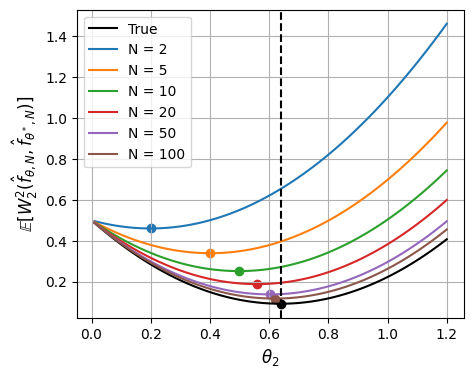

In [24]:
sigma1 = d_infty * theta

plt.figure(figsize=(5,4))
plt.plot(sig2_set, true_loss_exponential_gaussian_set, 'k', label='True')
plt.scatter(sigma1, true_wass_loss_exponential_gaussian(mu2, sigma1, theta, d_infty), marker='o', c='k')
for i, N in enumerate(Nset):
    plt.plot(sig2_set, expected_loss_exponential_gaussian_set[str(N)], label=f'N = {N}')
    # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
    temp_sigma = expected_loss_exponential_gaussian_minimizer_set[str(N)]
    plt.scatter(temp_sigma, expected_W_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]), marker='o')
plt.axvline([sigma1], color="k", linestyle="dashed")
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[W_2^2(\hat{f}_{\theta, N}, \hat{f}_{\theta^*, N})]$', fontsize=12)
plt.legend()
# plt.savefig(f'./fig_expected_loss_gaussian.pdf', format='pdf', bbox_inches="tight", dpi=300)

In [25]:
sigma1s_ = sig2_set
expected_was_diagonal_ = np.empty((len(Nset), len(sigma1s_)))
for i, N in enumerate(Nset):
    for j, sig1 in enumerate(sigma1s_):
        expected_was_diagonal_[i,j] = expected_wasserstein_loss_gaussian(mu2, sig1, mu2, sig1, N, m1s=m1s_set[str(N)])

In [97]:
def plot_rawdata(sig2_set, raw_data, N, reg, key, color=None, ls='-', plot_scatter=True):
    if N == 'infty':
        label = rf'$\epsilon$ = {reg}, N = $\infty$'
    else:
        label = rf'$\epsilon$ = {reg}, N = {N}'
    if color is None:
        line, = plt.plot(sig2_set, raw_data, label=label, ls=ls)
    else:
        line, = plt.plot(sig2_set, raw_data, label=label, color=color, ls=ls)
    # f = interp1d(sig2_set, raw_data, kind='cubic')   # or 'quadratic', 'linear'
    spline = UnivariateSpline(sig2_set, raw_data, s=1, k=5)
    new_data = spline(sig2_set)
    # plt.plot(sig2_set, new_data, '--', color=line.get_color())
    res = minimize_scalar(spline, bounds=(sig2_set.min(), sig2_set.max()), method='bounded')
    x_min = res.x
    y_min = spline(x_min)
    if plot_scatter:
        plt.scatter(x_min, y_min, marker='o', color=line.get_color())
    print(f"reg: {reg}, x_min: {x_min:.4f}")
    return line

reg: 0.2, x_min: 0.1719
reg: 0.2, x_min: 0.4045
reg: 0.2, x_min: 0.5095
reg: 0.2, x_min: 0.5657
reg: 0.2, x_min: 0.6045
reg: 0.2, x_min: 0.6205
reg: 0.2, x_min: 0.6347


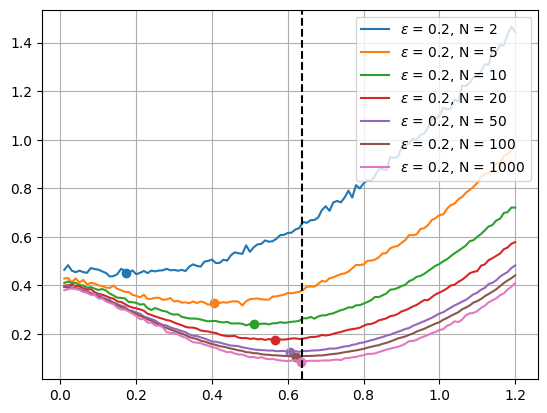

In [177]:
N_set_merge = [2, 5, 10, 20, 50, 100]
# N_set_merge = [20]

# for j,reg in enumerate([1, 2, 5, 10, 20, 100]):
for j,reg in enumerate([0.2]):
    for i,N in enumerate(N_set_merge):
        # if N != 5:
        #     continue
        # if j == 0:    
        #     plt.plot(sig2_set, expected_loss_exponential_gaussian_set[str(N)], label=rf'$\epsilon$ = 0, N = {N}')
        #     # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
        #     temp_sigma = expected_loss_exponential_gaussian_minimizer_set[str(N)]
        #     plt.scatter(temp_sigma, expected_W_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]), marker='d')
        #     print(f"reg: 0, x_min: {temp_sigma:.4f}")
    
    
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

    N=1000
    raw_data = results_merge_temp_N1000[str(reg)]['sink_div_emp'][0].mean(axis=-1)
    ent_part = results_merge_temp_N1000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    plot_rawdata(sig2_set, raw_data+reg*ent_part, N, reg, 'sink_div_full')
    
    raw_data = results_merge_temp_N1000[str(reg)]['sink_div_self'][0].mean(axis=-1)
    ent_part_self = results_merge_temp_N1000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    # plot_rawdata(sig2_set, raw_data+reg*ent_part_self, N, reg, 'sink_div_self_full')
    
    
    # N=5000
    # raw_data = results_merge_temp_N5000[str(reg)]['sink_div_emp'][0].mean(axis=-1)
    # ent_part = results_merge_temp_N5000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    # plot_rawdata(sig2_set, raw_data+reg*ent_part, N, reg, 'sink_div_full')
    
    # raw_data = results_merge_temp_N5000[str(reg)]['sink_div_self'][0].mean(axis=-1)
    # ent_part_self = results_merge_temp_N5000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    # # plot_rawdata(sig2_set, raw_data+reg*ent_part_self, N, reg, 'sink_div_self_full')


# plt.ylim(0,0.2)
plt.axvline([d_infty * theta], color="k", linestyle="dashed")
plt.grid()
plt.legend(loc='upper right')

reg: 0, x_min: 0.6186
reg: 0.2, x_min: 0.6205
reg: 0.5, x_min: 0.6360
reg: 1, x_min: 0.6559
reg: 2, x_min: 0.6732
reg: 5, x_min: 0.6762
reg: 10, x_min: 0.6601
reg: 20, x_min: 0.6251
reg: 100, x_min: 0.1304


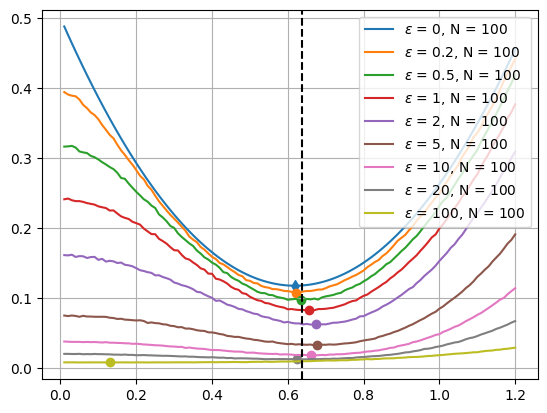

In [195]:
N_set_merge = [2, 5, 10, 20, 50, 100]
# N_set_merge = [20]

for j,reg in enumerate([0.2, 0.5, 1, 2, 5, 10, 20, 100]):
# for j,reg in enumerate([1]):
    for i,N in enumerate(N_set_merge):
        if N != 100:
            continue
        if j == 0:    
            plt.plot(sig2_set, expected_loss_exponential_gaussian_set[str(N)], label=rf'$\epsilon$ = 0, N = {N}')
            # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
            temp_sigma = expected_loss_exponential_gaussian_minimizer_set[str(N)]
            plt.scatter(temp_sigma, expected_W_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]), marker='d')
            print(f"reg: 0, x_min: {temp_sigma:.4f}")
    
    
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')


# plt.ylim(0,0.2)
plt.axvline([d_infty * theta], color="k", linestyle="dashed")
plt.grid()
plt.legend(loc='upper right')

In [179]:
# from raw means
dsig = 0.01
alpha_set = dict()
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    alphas = np.empty((len(N_set_merge), len(sig2_set)))
    raw1 = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1 += reg*ent_part
    raw1_deriv = np.zeros(raw1.shape)
    raw1_deriv[:,1:-1] = (raw1[:,2:] - raw1[:,:-2])/2/dsig
    raw1_deriv[:,0] = (raw1[:,1] - raw1[:,0])/dsig
    raw1_deriv[:,-1] = (raw1[:,-1] - raw1[:,-2])/dsig
    
    raw2 = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2 += reg*ent_part_self
    raw2_deriv = np.zeros(raw2.shape)
    raw2_deriv[:,1:-1] = (raw2[:,2:] - raw2[:,:-2])/2/dsig
    raw2_deriv[:,0] = (raw2[:,1] - raw2[:,0])/dsig
    raw2_deriv[:,-1] = (raw2[:,-1] - raw2[:,-2])/dsig
    
    alphas = raw1_deriv / raw2_deriv
    alpha_set[str(reg)] = alphas

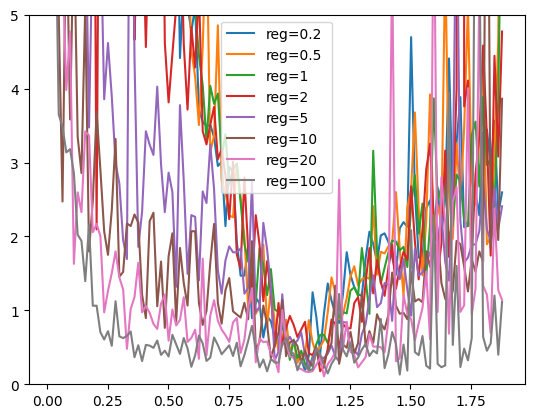

In [180]:
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    plt.plot(sig2_set/(d_infty * theta), np.std(alpha_set[str(reg)], axis=0), label=f'reg={reg}')
plt.ylim(0,5)
plt.legend()

In [181]:
# from smoothed means
dsig = 0.01
alpha_set_smooth = dict()
s=1
k=5
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    alphas = np.empty((len(N_set_merge), len(sig2_set)))
    raw1_ = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1_ += reg*ent_part
    raw1 = np.zeros(raw1_.shape)
    for i in range(len(raw1)):
        spline = UnivariateSpline(sig2_set, raw1_[i], s=s, k=k)
        raw1[i] = spline(sig2_set)
    raw1_deriv = np.zeros(raw1.shape)
    raw1_deriv[:,1:-1] = (raw1[:,2:] - raw1[:,:-2])/2/dsig
    raw1_deriv[:,0] = (raw1[:,1] - raw1[:,0])/dsig
    raw1_deriv[:,-1] = (raw1[:,-1] - raw1[:,-2])/dsig
    
    raw2_ = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2_ += reg*ent_part_self
    raw2 = np.zeros(raw2_.shape)
    for i in range(len(raw2)):
        spline = UnivariateSpline(sig2_set, raw2_[i], s=s, k=k)
        raw2[i] = spline(sig2_set)
    raw2_deriv = np.zeros(raw2.shape)
    raw2_deriv[:,1:-1] = (raw2[:,2:] - raw2[:,:-2])/2/dsig
    raw2_deriv[:,0] = (raw2[:,1] - raw2[:,0])/dsig
    raw2_deriv[:,-1] = (raw2[:,-1] - raw2[:,-2])/dsig
    
    alphas = raw1_deriv / raw2_deriv
    alpha_set_smooth[str(reg)] = alphas

    

reg: 0.2, sig: 0.64, ratio: 1.0021, alpha_mean: 0.5514, alpha_std: 0.0442
reg: 0.5, sig: 0.65, ratio: 1.0178, alpha_mean: 0.5024, alpha_std: 0.0273
reg: 1, sig: 0.67, ratio: 1.0491, alpha_mean: 0.4998, alpha_std: 0.0381
reg: 2, sig: 0.69, ratio: 1.0804, alpha_mean: 0.5046, alpha_std: 0.0305
reg: 5, sig: 0.70, ratio: 1.0961, alpha_mean: 0.4883, alpha_std: 0.0280
reg: 10, sig: 0.70, ratio: 1.0961, alpha_mean: 0.4837, alpha_std: 0.0197
reg: 20, sig: 0.71, ratio: 1.1117, alpha_mean: 0.5038, alpha_std: 0.0102
reg: 100, sig: 0.71, ratio: 1.1117, alpha_mean: 0.5030, alpha_std: 0.0044


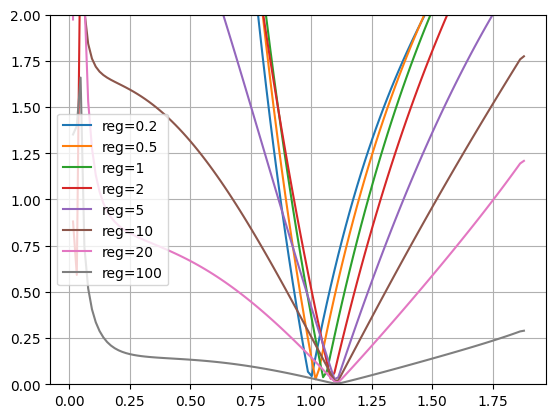

In [182]:
sig2_from_alpha_set = dict()
alpha_dagger_set = dict()
for reg in [0.2, 0.5, 1, 2, 5, 10, 20, 100]:
    cur_std = np.std(alpha_set_smooth[str(reg)], axis=0)
    plt.plot(sig2_set/(d_infty * theta), cur_std, label=f'reg={reg}')
    idx = np.argmin(cur_std)
    sig2_from_alpha_set[str(reg)] = sig2_set[idx]
    alpha_dagger_set[str(reg)] = np.mean(alpha_set_smooth[str(reg)][:,idx])
    print(f"reg: {reg}, sig: {sig2_set[idx]:.2f}, ratio: {sig2_set[idx]/(d_infty * theta):.4f}, alpha_mean: {np.mean(alpha_set_smooth[str(reg)][:,idx]):.4f}, alpha_std: {np.std(alpha_set_smooth[str(reg)][:,idx]):.4f}")
plt.ylim([0,2])
plt.grid()
plt.legend()

In [169]:
# alpha_set_noreg = dict()
# sig2_from_alpha_set_noreg = dict()
# alpha_dagger_set_noreg = dict()

def alpha_var_func_noreg(sig, return_alpha=False):
    temp_alpha = []
    # for i, N in enumerate([5, 10, 20, 50, 100]):
    for i, N in enumerate(N_set_merge):
        _, g1 = expected_W_exponential_gaussian_grad(theta, mu2, sig, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)])
        _, g2 = expected_wasserstein_loss_gaussian_self_grad(mu2, sig, N, m1s=m1s_set[str(N)])
        temp_alpha.append(g1 / g2)
    if return_alpha:
        return np.var(temp_alpha, axis=0), np.array(temp_alpha)
    return np.var(temp_alpha, axis=0)

res = minimize_scalar(alpha_var_func_noreg, bounds=(sig2_set.min(), sig2_set.max()), method='bounded')
x_min_noreg = res.x
val_noreg, alphas_noreg = alpha_var_func_noreg(x_min_noreg, return_alpha=True)
alpha_std_noreg = np.sqrt(np.array([alpha_var_func_noreg(sig) for sig in sig2_set]))
alphas_noreg, x_min_noreg

(array([0.5035659 , 0.51234558, 0.52027671, 0.52656889, 0.52568355,
        0.50913623]),
 0.6363767190022954)

In [170]:
d_infty * theta

0.6386569253748576

reg: 0.2, sig: 0.6360, ratio: 0.9959, alpha_mean: 0.5132, alpha_std: 0.0117
reg: 1, sig: 0.6733, ratio: 1.0543, alpha_mean: 0.5298, alpha_std: 0.0177
reg: 5, sig: 0.7042, ratio: 1.1027, alpha_mean: 0.5105, alpha_std: 0.0107


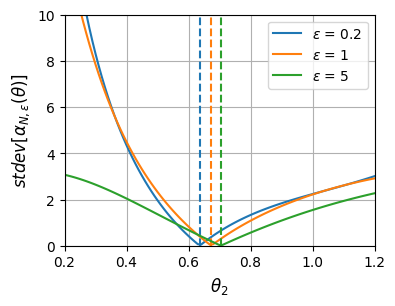

In [198]:
# from smoothed means
dsig = 0.01
alpha_set_smooth_v2 = dict()
sig2_from_alpha_set_v2 = dict()
alpha_dagger_set_v2 = dict()
s=1
k=5

plt.figure(figsize=(4,3))

# line, = plt.plot(sig2_set, alpha_std_noreg, label=rf'$\epsilon$ = 0')
# plt.axvline([x_min_noreg], color=line.get_color(), linestyle="dashed")
# print(f"reg: 0, sig: {x_min_noreg:.4f}, ratio: {x_min_noreg/(d_infty * theta):.4f}, alpha_mean: {np.mean(alphas_noreg):.4f}, alpha_std: {np.std(alphas_noreg):.4f}")

# for reg in [1, 2, 5, 10, 20, 100]:
for reg in [0.2,1,5]:
    raw1_ = results_merge[str(reg)]['sink_div_emp'].mean(axis=-1)
    ent_part = results_merge[str(reg)]['ent_xy'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'].mean(axis=-1))
    raw1_ += reg*ent_part
    dsplines = dict()
    for i, N in enumerate(N_set_merge):
        spline = UnivariateSpline(sig2_set, raw1_[i], s=s, k=k)
        dsplines[str(N)] = spline.derivative()
    
    raw2_ = results_merge[str(reg)]['sink_div_self'].mean(axis=-1)
    ent_part_self = results_merge[str(reg)]['ent_yy_indep'].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'].mean(axis=-1))
    raw2_ += reg*ent_part_self
    dsplines_self = dict()
    for i, N in enumerate(N_set_merge):
        spline = UnivariateSpline(sig2_set, raw2_[i], s=s, k=k)
        dsplines_self[str(N)] = spline.derivative()

    def alpha_var_func(sig, return_alpha=False):
        temp_alpha = []
        for i, N in enumerate(N_set_merge):
            temp_alpha.append(dsplines[str(N)](sig) / dsplines_self[str(N)](sig))
        if return_alpha:
            return np.var(temp_alpha, axis=0), np.array(temp_alpha)
        return np.var(temp_alpha, axis=0)
        
    res = minimize_scalar(alpha_var_func, bounds=(sig2_set.min(), sig2_set.max()), method='bounded')
    x_min = res.x
    val, alphas = alpha_var_func(x_min, return_alpha=True)
    
    alpha_set_smooth_v2[str(reg)] = alphas

    _, cur_alphas = alpha_var_func(sig2_set, return_alpha=True)
    cur_std = np.std(cur_alphas, axis=0)
    line, = plt.plot(sig2_set, cur_std, label=rf'$\epsilon$ = {reg}')
    # plt.scatter(x_min/(d_infty * theta), np.sqrt(val))
    sig2_from_alpha_set_v2[str(reg)] = x_min
    alpha_dagger_set_v2[str(reg)] = np.mean(alpha_set_smooth_v2[str(reg)])
    plt.axvline([x_min], color=line.get_color(), linestyle="dashed")
    print(f"reg: {reg}, sig: {x_min:.4f}, ratio: {x_min/(d_infty * theta):.4f}, alpha_mean: {np.mean(alpha_set_smooth_v2[str(reg)]):.4f}, alpha_std: {np.std(alpha_set_smooth_v2[str(reg)]):.4f}")

plt.xlim(0.2,1.2)
plt.ylim(0,10)
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$stdev[\alpha_{N,\epsilon}(\theta)]$', fontsize=12)
plt.legend()
# plt.ylim(2.5,2.52)
# plt.savefig(f'./fig_stdev_alpha_sinkhorn_mis.pdf', format='pdf', bbox_inches="tight", dpi=300)

(36, 120)
1.080392261612143, [0.50960975 0.53769724 0.59066751 0.64380847 0.7866665  0.98784525
 0.50591631 0.51753262 0.5344894  0.52418193 0.50497033 0.44030444
 0.49978136 0.4930217  0.49706306 0.46482893 0.40551772 0.24933179
 0.49983774 0.48772224 0.48796486 0.46949758 0.42612298 0.33126822
 0.50098965 0.48616127 0.48431709 0.47920862 0.45792027 0.3915573
 0.49835068 0.49688712 0.5068048  0.49939079 0.49154683 0.47931159]


(0.0, 10.0)

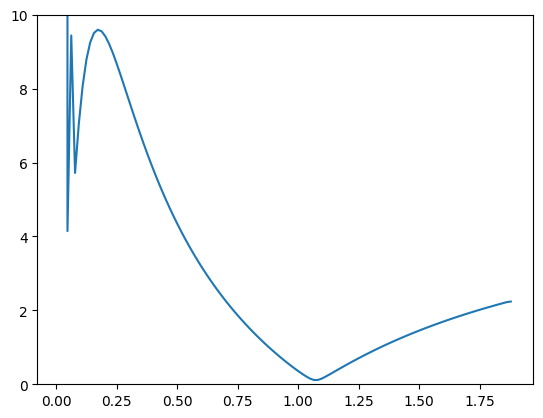

In [113]:
alpha_stack = []
for reg in [1, 2, 5, 10, 20, 100]:
    alpha_stack.append(alpha_set_smooth[str(reg)])
alpha_stack = np.concatenate(alpha_stack)
print(alpha_stack.shape)
cur_std = np.std(alpha_stack, axis=0)
plt.plot(sig2_set/(d_infty * theta), cur_std, label=f'reg={reg}')
idx = np.argmin(cur_std)
print(f"{sig2_set[idx]/(d_infty * theta)}, {alpha_stack[:,idx]}")
plt.ylim([0,10])

reg: 0.2, x_min: 0.5095
reg: 0.2, x_min: 0.5657
reg: 0.2, x_min: 0.6347
reg: 5, x_min: 0.3888
reg: 5, x_min: 0.5555
reg: 5, x_min: 0.7035


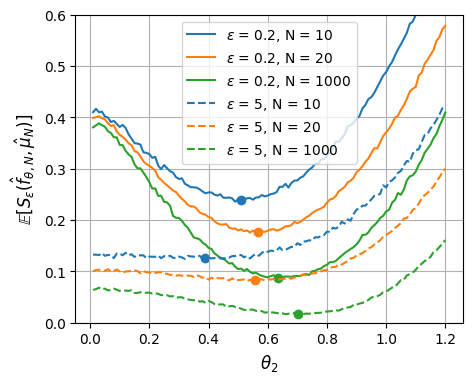

In [193]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
sig2_set=np.linspace(0.01,1.2,120)

plt.figure(figsize=(5,4))
# for j,reg in enumerate([1, 2, 5, 10, 20, 100]):
for j,reg in enumerate([0.2, 5]):
    runidx = 0
    for i,N in enumerate(N_set_merge):
        if N != 10 and N != 20:
            continue
        # alpha = 0.5
        # alpha = 0
        # line, = plt.plot(sig2_set, expected_loss_exponential_gaussian_set[str(N)] - alpha*expected_was_diagonal_[i], label=f'N = {N}, eps=0')
        # # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
        # temp_sigma = d_infty * theta
        # plt.scatter(temp_sigma, expected_W_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]) \
        #             - alpha*expected_wasserstein_loss_gaussian(mu2, temp_sigma, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='d')
        
        # plt.axvline([d_infty * theta], color=line.get_color(), linestyle="dashed")
        # print(f"reg: 0, x_min: {temp_sigma:.4f}, N:{N}")
        
    
        # alpha = alpha_dagger_set_v2[str(reg)]
        alpha = 0
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data_full = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        # plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data_self = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self
        
        raw_data = raw_data_full - alpha*raw_data_self

        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')

        runidx += 1
    
    N=1000
    ent_part = results_merge_temp_N1000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    raw_data_full = results_merge_temp_N1000[str(reg)]['sink_div_emp'][0].mean(axis=-1) + reg*ent_part
    ent_part_self = results_merge_temp_N1000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    raw_data_self = results_merge_temp_N1000[str(reg)]['sink_div_self'][0].mean(axis=-1) + reg*ent_part_self
    raw_data = raw_data_full - alpha*raw_data_self
    if j == 0:
        line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
        colors.append(line.get_color())
    else:
        plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')
    runidx += 1
        
    # N=5000
    # ent_part = results_merge_temp_N5000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    # raw_data_full = results_merge_temp_N5000[str(reg)]['sink_div_emp'][0].mean(axis=-1) + reg*ent_part
    # ent_part_self = results_merge_temp_N5000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    # raw_data_self = results_merge_temp_N5000[str(reg)]['sink_div_self'][0].mean(axis=-1) + reg*ent_part_self
    # raw_data = raw_data_full - alpha*raw_data_self
    # if j == 0:
    #     line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
    #     colors.append(line.get_color())
    # else:
    #     plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')
    # runidx += 1


    # plt.axvline([sig2_from_alpha_set_v2[str(reg)]], color=line.get_color(), linestyle="dashed")
    # print(f"sig from alpha: {sig2_from_alpha_set_v2[str(reg)]:.4f}")
plt.ylim(0,0.6)
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{\mu}_{N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()
# plt.savefig(f'./fig_sinkhorn_gaussian_mis.pdf', format='pdf', bbox_inches="tight", dpi=300)

reg: 0.2, x_min: 0.6376
reg: 0.2, x_min: 0.6343
0.008549954044920278 2.2570774946429125e-07
reg: 0.2, x_min: 0.6364
sig from alpha: 0.6360
reg: 5, x_min: 0.6991
reg: 5, x_min: 0.7039
0.005261688693695132 2.0318241978866053e-07
reg: 5, x_min: 0.7062
sig from alpha: 0.7042


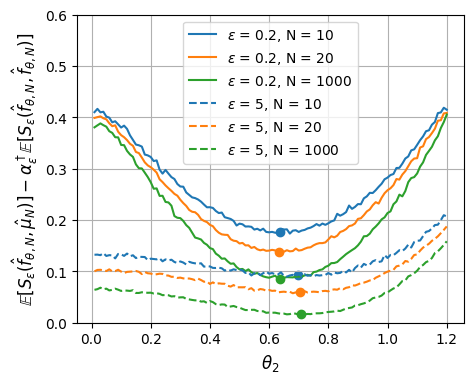

In [197]:
N_set_merge = [2, 5, 10, 20, 50, 100]
colors = []
sig2_set=np.linspace(0.01,1.2,120)

plt.figure(figsize=(5,4))
# for j,reg in enumerate([1, 2, 5, 10, 20, 100]):
for j,reg in enumerate([0.2, 5]):
    runidx = 0
    for i,N in enumerate(N_set_merge):
        if N != 10 and N != 20:
            continue
        # alpha = 0.5
        # alpha = 0
        # line, = plt.plot(sig2_set, expected_loss_exponential_gaussian_set[str(N)] - alpha*expected_was_diagonal_[i], label=f'N = {N}, eps=0')
        # # plt.plot(sigma2s, np.mean(empirical_loss_gaussian_set[str(N)], axis=1), '--', c=plt.gca().lines[-1].get_color())
        # temp_sigma = d_infty * theta
        # plt.scatter(temp_sigma, expected_W_exponential_gaussian(theta, mu2, temp_sigma, N, m1s_exp=m1s_exp_set[str(N)], m1s=m1s_set[str(N)]) \
        #             - alpha*expected_wasserstein_loss_gaussian(mu2, temp_sigma, mu2, temp_sigma, N, m1s=m1s_set[str(N)]), marker='d')
        
        # plt.axvline([d_infty * theta], color=line.get_color(), linestyle="dashed")
        # print(f"reg: 0, x_min: {temp_sigma:.4f}, N:{N}")
        
    
        alpha = alpha_dagger_set_v2[str(reg)]
        # alpha = 0
        ent_part = results_merge[str(reg)]['ent_xy'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_xx'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1))
        raw_data_full = results_merge[str(reg)]['sink_div_emp'][i].mean(axis=-1) + reg*ent_part
        # plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_full')

        ent_part_self = results_merge[str(reg)]['ent_yy_indep'][i].mean(axis=-1) - 0.5*(results_merge[str(reg)]['ent_yy_same'][i].mean(axis=-1) + results_merge[str(reg)]['ent_yy_same2'][i].mean(axis=-1))
        raw_data_self = results_merge[str(reg)]['sink_div_self'][i].mean(axis=-1) + reg*ent_part_self
        
        raw_data = raw_data_full - alpha*raw_data_self

        if j == 0:
            line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
            colors.append(line.get_color())
        else:
            plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')

        runidx += 1
    
    N=1000
    ent_part = results_merge_temp_N1000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    raw_data_full = results_merge_temp_N1000[str(reg)]['sink_div_emp'][0].mean(axis=-1) + reg*ent_part
    ent_part_self = results_merge_temp_N1000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N1000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N1000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    raw_data_self = results_merge_temp_N1000[str(reg)]['sink_div_self'][0].mean(axis=-1) + reg*ent_part_self
    raw_data = raw_data_full - alpha*raw_data_self
    print(raw_data_self.max(), raw_data_self.min())
    if j == 0:
        line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
        colors.append(line.get_color())
    else:
        plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')
    runidx += 1
        
    # N=5000
    # ent_part = results_merge_temp_N5000[str(reg)]['ent_xy'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_xx'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1))
    # raw_data_full = results_merge_temp_N5000[str(reg)]['sink_div_emp'][0].mean(axis=-1) + reg*ent_part
    # ent_part_self = results_merge_temp_N5000[str(reg)]['ent_yy_indep'][0].mean(axis=-1) - 0.5*(results_merge_temp_N5000[str(reg)]['ent_yy_same'][0].mean(axis=-1) + results_merge_temp_N5000[str(reg)]['ent_yy_same2'][0].mean(axis=-1))
    # raw_data_self = results_merge_temp_N5000[str(reg)]['sink_div_self'][0].mean(axis=-1) + reg*ent_part_self
    # raw_data = raw_data_full - alpha*raw_data_self
    # if j == 0:
    #     line = plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias')
    #     colors.append(line.get_color())
    # else:
    #     plot_rawdata(sig2_set, raw_data, N, reg, 'sink_div_debias', color=colors[runidx], ls='--')
    # runidx += 1


    # plt.axvline([sig2_from_alpha_set_v2[str(reg)]], color='k', linestyle="dashed")
    print(f"sig from alpha: {sig2_from_alpha_set_v2[str(reg)]:.4f}")
plt.ylim(0,0.6)
plt.grid()
plt.xlabel(r'$\theta_2$', fontsize=12)
plt.ylabel(r'$\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{\mu}_{N})] - \alpha^\dagger_\epsilon\mathbb{E}[S_{\epsilon}(\hat{f}_{\theta, N}, \hat{f}_{\theta, N})]$', fontsize=12)
# plt.legend(loc='upper right')
plt.legend()
# plt.savefig(f'./fig_sinkhorn_gaussian_mis_debias.pdf', format='pdf', bbox_inches="tight", dpi=300)